# Convex-Cost Swing Option: RL vs LSM

> Comparative diagnostics for the convex frictions experiment (`c_cost=0.05`, `gamma_cost=2.0`) using the evaluation logs at `logs/SwingOption_20_c0.05_gamma2_16`. The focus is on pricing accuracy, allocation behaviour, and how convex exercise frictions propagate through both the Longstaff–Schwartz benchmark and the reinforcement learning policy.

## Research framing
- Monthly HHK swing contract: 22 exercise rights, $Q_{\max}=20$, strike $K=1.0$, refraction disabled.
- Experiment introduces convex execution frictions governed by $c_{\text{cost}}=0.05$ and $\gamma_{\text{cost}}=2.0$.
- Goal: quantify how RL and LSM differ in **pricing**, **exercise timing**, **quantity allocation**, and **cost efficiency** under convex frictions.
- Approach: load evaluation CSVs, engineer discounted payoffs and cost decompositions, and contrast distributions/behaviours with statistical tests plus visual diagnostics.

In [1]:
# Core analysis stack
import json
from pathlib import Path
from typing import Dict, Tuple
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import colors as mcolors
from scipy import stats
from sklearn.utils import resample
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
# File locations and contract parameters
DATA_ROOT = Path("/Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/SwingOption_20_v2_c0.05_gamma2_11/evaluations")
LSM_PATH = DATA_ROOT / "lsm.csv"
RL_PATH = DATA_ROOT / "rl_episode_6144.csv"
assert LSM_PATH.exists() and RL_PATH.exists(), "Evaluation CSVs missing - verify the chosen run."
K = 1.0
R = 0.05
MATURITY = 0.0833  # ~1 month
N_RIGHTS = 22
DT = MATURITY / N_RIGHTS
Q_MAX = 20.0
C_COST = 0.05
GAMMA_COST = 2.0
DISCOUNT = np.exp(-R * DT * (np.arange(N_RIGHTS) + 1))
print(f"Δt = {DT:.5f}, discount[0] = {DISCOUNT[0]:.6f}")

Δt = 0.00379, discount[0] = 0.999811


In [3]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    renamed = df.copy()
    renamed.columns = [c.strip().lower() for c in renamed.columns]
    return renamed


def add_discounting(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['time_step'] = df['time_step'].astype(int)
    df['discount'] = np.exp(-R * DT * (df['time_step'] + 1))
    return df


def prepare_lsm(path: Path) -> pd.DataFrame:
    df = clean_columns(pd.read_csv(path))
    df = add_discounting(df)
    df['pv_net'] = df['payoff'] * df['discount']
    df['pv_gross'] = df['payoff_gross'] * df['discount']
    df['pv_cost'] = df['exercise_cost'] * df['discount']
    df['costs'] = df['exercise_cost']
    df['costs_discounted'] = df['pv_cost']
    df['method'] = 'LSM'
    return df


def prepare_rl(path: Path) -> pd.DataFrame:
    df = clean_columns(pd.read_csv(path))
    df = add_discounting(df)
    intrinsic = df['spot_minus_strike'] if 'spot_minus_strike' in df.columns else (df['spot'] - K)
    df['gross_payoff'] = np.maximum(intrinsic, 0.0) * df['q_t']
    df['exercise_cost_model'] = C_COST * np.power(np.clip(df['q_t'], 0.0, None), GAMMA_COST)
    df['pv_gross'] = df['gross_payoff'] * df['discount']
    df['pv_cost'] = df['exercise_cost_model'] * df['discount']
    df['net_payoff'] = df['reward'] if 'reward' in df.columns else df['payoff']
    df['pv_net'] = df['net_payoff'] if 'reward' in df.columns else df['net_payoff'] * df['discount']
    df['reward_raw'] = df['reward'] if 'reward' in df.columns else np.nan
    df['costs'] = np.maximum(df['gross_payoff'] - df['net_payoff'], 0.0)
    df['costs_discounted'] = df['costs'] * df['discount']
    df['q_exercised'] = df.get('q_exercised_norm', 0.0) * Q_MAX
    df['q_remaining'] = df.get('q_remaining_norm', 0.0) * Q_MAX
    df['method'] = 'RL'
    return df


def per_path_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    g = df.groupby(['method', 'path'], as_index=False)
    agg = g.agg(
        PV_net=('pv_net', 'sum'),
        PV_gross=('pv_gross', 'sum'),
        PV_cost=('pv_cost', 'sum'),
        Q_total=('q_t', 'sum'),
        Costs_total=('costs', 'sum'),
        Costs_discounted_total=('costs_discounted', 'sum')
    )
    first_ex = (
        df[df['q_t'] > 1e-8]
        .groupby(['method', 'path'])['time_step']
        .min()
        .rename('first_ex')
        .reset_index()
    )
    agg = agg.merge(first_ex, on=['method', 'path'], how='left')
    agg['PV_margin_pct'] = np.where(agg['PV_gross'] > 0, 1 - agg['PV_net'] / agg['PV_gross'], np.nan)
    return agg

In [4]:
lsm_df = prepare_lsm(LSM_PATH)
rl_df = prepare_rl(RL_PATH)
combined = pd.concat([lsm_df, rl_df], ignore_index=True)
print(f"LSM rows: {len(lsm_df):,} | RL rows: {len(rl_df):,}")
print(f"Columns: {sorted(combined.columns)[:10]} ...")
if 'reward_raw' in rl_df.columns:
    rl_diff = (rl_df['pv_net'] - rl_df['reward_raw']).abs().max()
    print(f"Max abs difference between pv_net and raw reward: {rl_diff:.3e}")

LSM rows: 90,112 | RL rows: 89,286
Columns: ['costs', 'costs_discounted', 'days_since_exercise_norm', 'discount', 'exercise_cost', 'exercise_cost_model', 'gross_payoff', 'method', 'net_payoff', 'normalized_time'] ...
Max abs difference between pv_net and raw reward: 0.000e+00


In [5]:
path_stats = per_path_metrics(combined)
path_stats.head()

,method,path,PV_net,PV_gross,PV_cost,Q_total,Costs_total,Costs_discounted_total,first_ex,PV_margin_pct
0,LSM,0,0.371981,1.169562,0.797581,8.0,0.8,0.797581,6.0,0.681948
1,LSM,1,0.000000,0.000000,0.000000,0.0,0.0,0.000000,NaN,NaN
2,LSM,2,0.000000,0.000000,0.000000,0.0,0.0,0.000000,NaN,NaN
3,LSM,3,4.643137,6.637315,1.994178,20.0,2.0,1.994178,9.0,0.300449
4,LSM,4,0.658889,1.854958,1.196069,12.0,1.2,1.196069,10.0,0.644796


## Price, volume, and cost summaries
Key diagnostics at the path level: net PV (discounted), gross PV before friction, cumulative cost outlay, quantity consumed, and first-exercise timing. Confidence intervals are based on Student-$t$ with per-path samples ($n=4096$ per method).

In [6]:
def ci95(series: pd.Series) -> Tuple[float, float]:
    arr = series.to_numpy(dtype=float)
    n = len(arr)
    mean = np.nanmean(arr)
    std = np.nanstd(arr, ddof=1)
    se = std / np.sqrt(n) if n > 0 else np.nan
    half = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan
    return mean, half


summary_rows = []
for method, grp in path_stats.groupby('method'):
    pv_mean, pv_ci = ci95(grp['PV_net'])
    q_mean, q_ci = ci95(grp['Q_total'])
    cost_mean, cost_ci = ci95(grp['PV_cost'])
    gross_mean, gross_ci = ci95(grp['PV_gross'])
    first_mean, first_ci = ci95(grp['first_ex'].dropna())
    summary_rows.append({
        'method': method,
        'PV_net_mean': pv_mean,
        'PV_net_CI95': pv_ci,
        'PV_gross_mean': gross_mean,
        'PV_cost_mean': cost_mean,
        'Q_total_mean': q_mean,
        'first_ex_mean': first_mean,
        'first_ex_CI95': first_ci
    })

summary_df = pd.DataFrame(summary_rows).set_index('method').sort_index()
summary_df.style.format("{:.4f}")

,PV_net_mean,PV_net_CI95,PV_gross_mean,PV_cost_mean,Q_total_mean,first_ex_mean,first_ex_CI95
method,,,,,,,
LSM,1.6477,0.0698,2.4768,0.8291,8.3140,9.8728,0.2127
RL,1.7561,0.0691,2.4379,0.6820,8.9446,4.9380,0.1461


In [7]:
rl_paths = path_stats[path_stats['method'] == 'RL']
lsm_paths = path_stats[path_stats['method'] == 'LSM']

pv_t = stats.ttest_ind(rl_paths['PV_net'], lsm_paths['PV_net'], equal_var=False)
q_t = stats.ttest_ind(rl_paths['Q_total'], lsm_paths['Q_total'], equal_var=False)
first_t = stats.ttest_ind(rl_paths['first_ex'].dropna(), lsm_paths['first_ex'].dropna(), equal_var=False)

delta_metrics = {
    'Δ PV_mean': summary_df.loc['RL', 'PV_net_mean'] - summary_df.loc['LSM', 'PV_net_mean'],
    'Δ Q_mean': summary_df.loc['RL', 'Q_total_mean'] - summary_df.loc['LSM', 'Q_total_mean'],
    'Δ cost_mean': summary_df.loc['RL', 'PV_cost_mean'] - summary_df.loc['LSM', 'PV_cost_mean']
}

print("Welch t-tests (RL - LSM):")
print(f"  PV: t={pv_t.statistic:.3f}, p={pv_t.pvalue:.3g}")
print(f"  Quantity: t={q_t.statistic:.3f}, p={q_t.pvalue:.3g}")
print(f"  First exercise: t={first_t.statistic:.3f}, p={first_t.pvalue:.3g}")
print("\nMean deltas:")
for k, v in delta_metrics.items():
    print(f"  {k}: {v:.4f}")

Welch t-tests (RL - LSM):
  PV: t=2.165, p=0.0304
  Quantity: t=3.773, p=0.000163
  First exercise: t=-37.494, p=7.29e-274

Mean deltas:
  Δ PV_mean: 0.1084
  Δ Q_mean: 0.6306
  Δ cost_mean: -0.1471


## Price distributions and tail behaviour
Compare per-path discounted PVs to spot distributional differences and identify whether convex costs widen or compress RL dispersion relative to LSM.

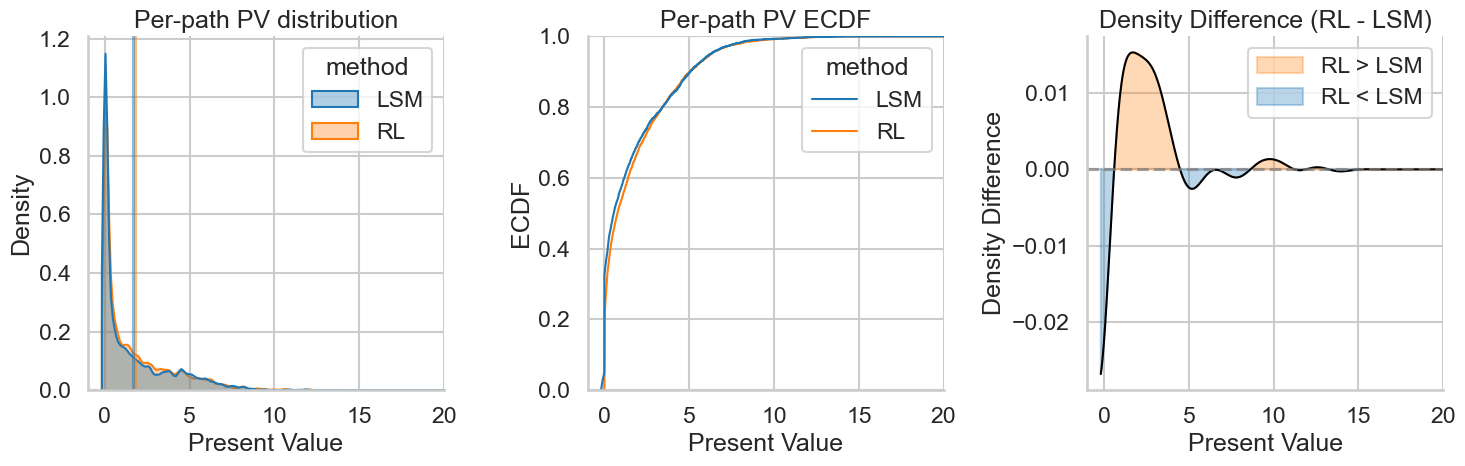

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Means
m_rl = summary_df.loc['RL', 'PV_net_mean']
m_lsm = summary_df.loc['LSM', 'PV_net_mean']

# KDE plot
sns.kdeplot(
    data=path_stats,
    x='PV_net',
    hue='method',
    palette={'RL': 'tab:orange', 'LSM': 'tab:blue'},
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=1.5,
    ax=axes[0],
    bw_adjust=0.3,
    clip=(path_stats['PV_net'].min(), path_stats['PV_net'].max()),
)
axes[0].axvline(m_rl, color='tab:orange', ymin=0, ymax=1, alpha=0.5, label=f'RL Mean: {m_rl:.4f}')
axes[0].axvline(m_lsm, color='tab:blue', ymin=0, ymax=1, alpha=0.5, label=f'LSM Mean: {m_lsm:.4f}')
axes[0].set_title('Per-path PV distribution')
axes[0].set_xlabel('Present Value')
axes[0].set_ylabel('Density')
axes[0].set_xlim(-1, 20)

# ECDF plot
sns.ecdfplot(
    data=path_stats,
    x='PV_net',
    hue='method',
    palette={'RL': 'tab:orange', 'LSM': 'tab:blue'},
    linewidth=1.5,
    ax=axes[1]
)
axes[1].set_title('Per-path PV ECDF')
axes[1].set_xlabel('Present Value')
axes[1].set_ylabel('ECDF')
axes[1].set_xlim(-1, 20)

# Density difference plot
rl_pv = path_stats[path_stats['method'] == 'RL']['PV_net'].values
lsm_pv = path_stats[path_stats['method'] == 'LSM']['PV_net'].values

kde_rl = stats.gaussian_kde(rl_pv, bw_method=0.3)  # Match bw_adjust from KDE plot
kde_lsm = stats.gaussian_kde(lsm_pv, bw_method=0.3)

x_grid = np.linspace(path_stats['PV_net'].min(), path_stats['PV_net'].max(), 1000)
rl_density = kde_rl(x_grid)
lsm_density = kde_lsm(x_grid)
density_diff = rl_density - lsm_density

axes[2].plot(x_grid, density_diff, color='black', linewidth=1.5)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[2].fill_between(x_grid, density_diff, 0, where=(density_diff > 0), color='tab:orange', alpha=0.3, label='RL > LSM')
axes[2].fill_between(x_grid, density_diff, 0, where=(density_diff < 0), color='tab:blue', alpha=0.3, label='RL < LSM')
axes[2].set_title('Density Difference (RL - LSM)')
axes[2].set_xlabel('Present Value')
axes[2].set_ylabel('Density Difference')
axes[2].set_xlim(-1, 20)
axes[2].legend()

plt.tight_layout()
plt.show()

## Cost decomposition
Separate gross exercise value, convex cost burn, and resulting net PV to see which engine better arbitrages the friction.

In [9]:
# path_stats.groupby('method')['PV_cost'].plot(kind='hist', alpha=0.5, bins=100)
path_stats.query('method == "LSM"')['PV_cost'].unique().size

1514

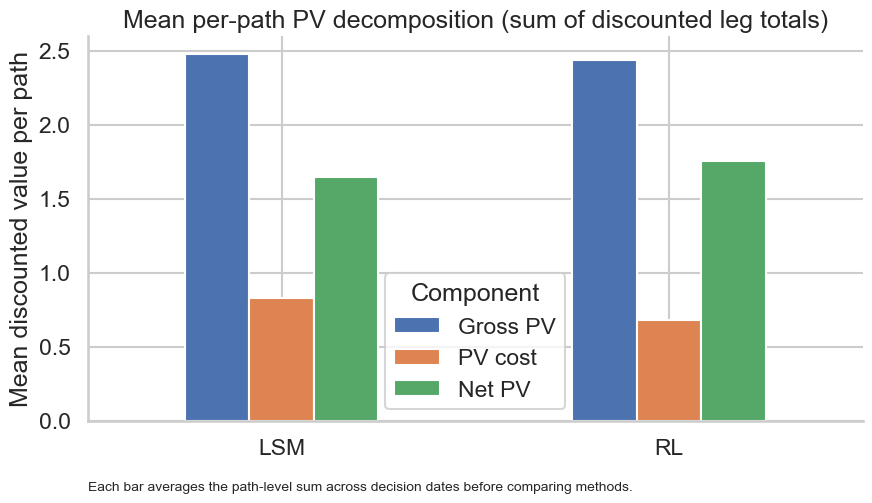

Size of unique PV_cost values for LSM: 1514
Size of unique PV_cost values for RL : 3511


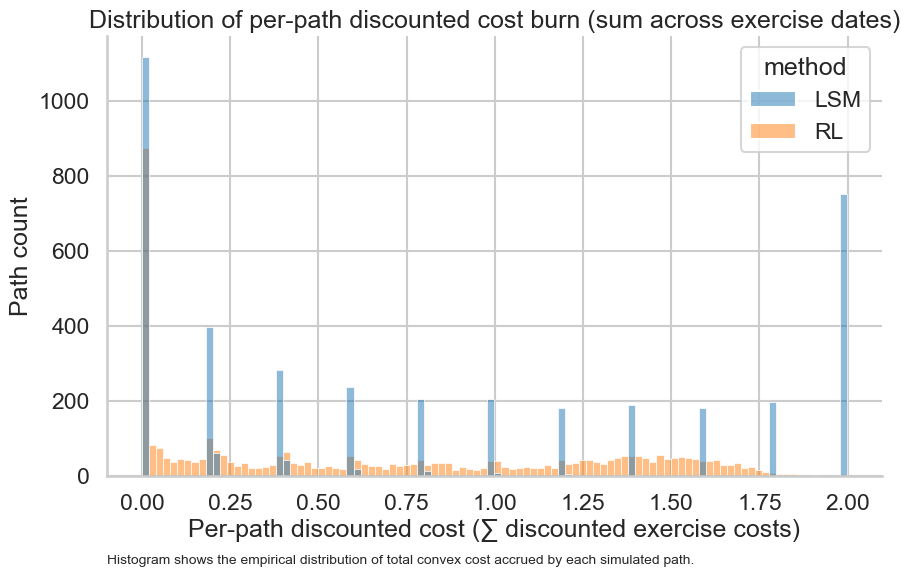

In [10]:
cost_view = summary_df[['PV_gross_mean', 'PV_cost_mean', 'PV_net_mean']].rename(columns={'PV_gross_mean': 'Gross PV', 'PV_cost_mean': 'PV cost', 'PV_net_mean': 'Net PV'})
fig, ax = plt.subplots(figsize=(10, 5))
cost_view.plot(kind='bar', color=['#4c72b0', '#dd8452', '#55a868'], ax=ax)
ax.set_title('Mean per-path PV decomposition (sum of discounted leg totals)')
ax.set_ylabel('Mean discounted value per path')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='best', title='Component')
ax.annotate('Each bar averages the path-level sum across decision dates before comparing methods.',
            xy=(0, -0.18), xycoords='axes fraction', fontsize=10)
# fig.subplots_adjust(bottom=0.58)
# plt.tight_layout()
plt.show()

count_lsm = path_stats.loc[path_stats['method'] == 'LSM', 'PV_cost'].nunique()
count_rl = path_stats.loc[path_stats['method'] == 'RL', 'PV_cost'].nunique()
print(f"Size of unique PV_cost values for LSM: {count_lsm}")
print(f"Size of unique PV_cost values for RL : {count_rl}")
del count_lsm, count_rl

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=path_stats, x='PV_cost', hue='method', bins=100, palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, ax=ax)
ax.set_title('Distribution of per-path discounted cost burn (sum across exercise dates)')
ax.set_xlabel('Per-path discounted cost (∑ discounted exercise costs)')
ax.set_ylabel('Path count')
ax.annotate('Histogram shows the empirical distribution of total convex cost accrued by each simulated path.',
            xy=(0, -0.2), xycoords='axes fraction', fontsize=10)
fig.subplots_adjust(bottom=-0.0)
# plt.tight_layout()
plt.show()

## Cost incidence diagnostics
Quantify how frequently each engine burns convex costs and whether the RL edge comes from cheaper execution or improved monetisation. Costs follow the requested construction: RL uses `spot_minus_strike − reward` while LSM uses the recorded `exercise_cost`.

In [11]:
# Per-path cost diagnostics
path_stats = path_stats.copy()
path_stats['cost_per_unit'] = path_stats['Costs_total'] / np.where(path_stats['Q_total'] > 1e-8, path_stats['Q_total'], np.nan)
path_stats['cost_share_gross'] = path_stats['Costs_total'] / np.where(path_stats['PV_gross'] > 1e-8, path_stats['PV_gross'], np.nan)
# Winsorize cost-per-unit to 1st-99th percentile to dampen extreme tails for visuals
cpu_q_low, cpu_q_high = path_stats['cost_per_unit'].quantile([0.01, 0.99])
path_stats['cost_per_unit_clipped'] = path_stats['cost_per_unit'].clip(cpu_q_low, cpu_q_high)
cost_rows = []
for method, grp in path_stats.groupby('method'):
    cost_mean, cost_ci = ci95(grp['Costs_total'])
    cost_disc_mean, cost_disc_ci = ci95(grp['Costs_discounted_total'])
    cpu_mean, cpu_ci = ci95(grp['cost_per_unit'].dropna())
    share_mean, share_ci = ci95(grp['cost_share_gross'].dropna())
    cost_rows.append({
        'method': method,
        'Cost_total_mean': cost_mean,
        'Cost_total_CI95': cost_ci,
        'Cost_discounted_mean': cost_disc_mean,
        'Cost_discounted_CI95': cost_disc_ci,
        'Cost_per_unit_mean': cpu_mean,
        'Cost_per_unit_CI95': cpu_ci,
        'Cost_share_gross_mean': share_mean,
        'Cost_share_gross_CI95': share_ci
    })
cost_summary = pd.DataFrame(cost_rows).set_index('method').sort_index()
cost_summary.style.format("{:.4f}")

,Cost_total_mean,Cost_total_CI95,Cost_discounted_mean,Cost_discounted_CI95,Cost_per_unit_mean,Cost_per_unit_CI95,Cost_share_gross_mean,Cost_share_gross_CI95
method,,,,,,,,
LSM,0.8314,0.0237,0.8291,0.0236,0.1000,0.0000,2.2470,1.9295
RL,0.6882,0.0186,0.6863,0.0185,0.0669,0.0008,0.3789,0.0057


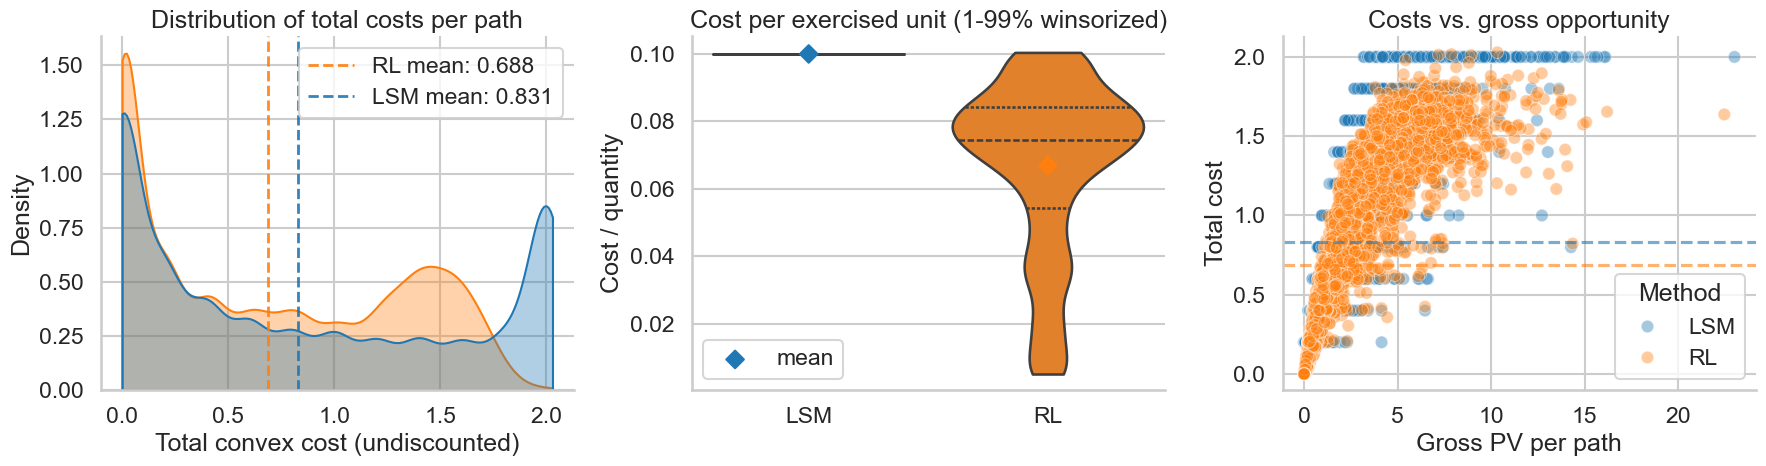

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {'RL': 'tab:orange', 'LSM': 'tab:blue'}
cost_max = path_stats['Costs_total'].max()
sns.kdeplot(
    data=path_stats,
    x='Costs_total',
    hue='method',
    fill=True,
    alpha=0.35,
    linewidth=1.5,
    common_norm=False,
    palette=palette,
    ax=axes[0],
    bw_adjust=0.6,
    clip=(0, cost_max)
 )
axes[0].set_title('Distribution of total costs per path')
axes[0].set_xlabel('Total convex cost (undiscounted)')
axes[0].set_ylabel('Density')
cost_means = path_stats.groupby('method')['Costs_total'].mean().to_dict()
for method, color in palette.items():
    value = cost_means.get(method)
    if np.isfinite(value):
        axes[0].axvline(value, color=color, linestyle='--', linewidth=2, alpha=0.9, label=f'{method} mean: {value:.3f}')
axes[0].legend()
order = ['LSM', 'RL']
sns.violinplot(
    data=path_stats,
    x='method',
    y='cost_per_unit_clipped',
    hue='method',
    palette=palette,
    cut=0,
    inner='quartile',
    order=order,
    legend=False,
    ax=axes[1]
 )
axes[1].set_title('Cost per exercised unit (1-99% winsorized)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cost / quantity')
cpu_means = path_stats.groupby('method')['cost_per_unit_clipped'].mean()
axes[1].scatter(list(range(len(order))), [cpu_means.get(m, np.nan) for m in order], c=[palette[m] for m in order], s=80, marker='D', zorder=10, label='mean')
axes[1].legend()
sns.scatterplot(
    data=path_stats,
    x='PV_gross',
    y='Costs_total',
    hue='method',
    palette=palette,
    alpha=0.4,
    ax=axes[2]
 )
axes[2].set_title('Costs vs. gross opportunity')
axes[2].set_xlabel('Gross PV per path')
axes[2].set_ylabel('Total cost')
for method, color in palette.items():
    sub = path_stats[path_stats['method'] == method]
    if not sub['Costs_total'].empty:
        axes[2].axhline(sub['Costs_total'].mean(), color=color, linestyle='--', alpha=0.6)
axes[2].legend(loc='best', title='Method')
plt.tight_layout()
plt.show()

# Maximum cumulative Cost:
$
Q_{max} \times 0.05 \times max(q_{t})^2 = 10 \times 0.05 2^2 = \textbf{2}
$

In [13]:
# show rows in LSM where exercise_cost > 0 and payoff > 0
rldf = pd.read_csv(RL_PATH)
rldf.query('reward < 0')

,path,time_step,spot_minus_strike,q_exercised_norm,q_remaining_norm,time_to_maturity_norm,normalized_time,spot,X_t,Y_t,days_since_exercise_norm,q_t,exercise_cost,reward


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

palette = {'RL': '#f28e2b', 'LSM': '#4e79a7'}
frames, path_view = {}, []
for method, path in (('RL', RL_PATH), ('LSM', LSM_PATH)):
    df = pd.read_csv(path).copy()
    df = df.query('q_t > 0')
    discount = np.exp(-R * (df['time_step'] + 1) * DT)
    if method == 'RL':
        df['reward_disc'] = df['reward']
    else:
        df['reward_disc'] = df['payoff'] * discount
    if 'exercise_cost' in df.columns:
        df['cost_disc'] = df['exercise_cost'] * discount
    else:
        spread = df['spot_minus_strike'] if 'spot_minus_strike' in df.columns else (df['spot'] - K)
        gross_disc = np.maximum(spread, 0.0) * df['q_t'] * discount
        df['cost_disc'] = gross_disc - df['reward_disc']
    df['method'] = method
    frames[method] = df
    path_view.append(
        df.groupby('path')[['cost_disc', 'reward_disc']].sum().assign(method=method)
    )
path_view = pd.concat(path_view, ignore_index=True)

fig = make_subplots(rows=2, cols=2, subplot_titles=(
    'Path Reward vs Cost',
    'Discounted Cost vs Spot',
    'Discounted Reward vs Spot',
    'Reward vs Spot (zoom)'
))

def add_scatter(data, x, y, row, col, method, showlegend=False):
    fig.add_trace(go.Scatter(
        x=data[x],
        y=data[y],
        mode='markers',
        name=method,
        legendgroup=method,
        showlegend=showlegend,
        marker=dict(color=palette[method], size=4, opacity=0.55)
    ), row=row, col=col)

for method, df in frames.items():
    add_scatter(path_view.query('method == @method'), 'cost_disc', 'reward_disc', 1, 1, method, True)
    add_scatter(df, 'spot', 'cost_disc', 1, 2, method)
    add_scatter(df, 'spot', 'reward_disc', 2, 1, method)
    add_scatter(df, 'spot', 'reward_disc', 2, 2, method)

axis_labels = {
    (1, 1): ('Discounted Cost', 'Discounted Reward'),
    (1, 2): ('Spot S(t)', 'Discounted Cost'),
    (2, 1): ('Spot S(t)', 'Discounted Reward'),
    (2, 2): ('Spot S(t)', 'Discounted Reward')
}
for (row, col), (xlab, ylab) in axis_labels.items():
    fig.update_xaxes(title_text=xlab, row=row, col=col)
    fig.update_yaxes(title_text=ylab, row=row, col=col)
fig.update_xaxes(range=[0.99, 1.7], row=2, col=2)
fig.update_yaxes(range=[-0.22, 1.25], row=2, col=2)
fig.update_layout(height=650, width=960, title_text='RL vs LSM Cost-Reward Diagnostics (q_t > 0)', hovermode='closest')
fig.show()

In [15]:
# Pairwise RL−LSM decomposition
rl_paths = path_stats[path_stats['method'] == 'RL'].copy()
lsm_paths = path_stats[path_stats['method'] == 'LSM'].copy()
paired_costs = (
    rl_paths[['path', 'PV_net', 'PV_gross', 'Q_total', 'Costs_total', 'cost_per_unit']]
    .merge(
        lsm_paths[['path', 'PV_net', 'PV_gross', 'Q_total', 'Costs_total', 'cost_per_unit']],
        on='path',
        suffixes=('_RL', '_LSM')
    )
)
paired_costs['delta_PV'] = paired_costs['PV_net_RL'] - paired_costs['PV_net_LSM']
paired_costs['delta_gross'] = paired_costs['PV_gross_RL'] - paired_costs['PV_gross_LSM']
paired_costs['delta_costs'] = paired_costs['Costs_total_RL'] - paired_costs['Costs_total_LSM']
paired_costs['delta_cpu'] = paired_costs['cost_per_unit_RL'] - paired_costs['cost_per_unit_LSM']
cost_dominated_share = (paired_costs['delta_costs'] < 0).mean()
gross_dominated_share = (paired_costs['delta_gross'] > 0).mean()
print(f"Fraction of paths where RL spends less: {cost_dominated_share:.2%}")
print(f"Fraction of paths where RL creates more gross value: {gross_dominated_share:.2%}")
mean_delta_costs = paired_costs['delta_costs'].mean()
mean_delta_gross = paired_costs['delta_gross'].mean()
mean_delta_pv = paired_costs['delta_PV'].mean()
print(f"Mean Δgross: {mean_delta_gross:.4f} | Mean Δcosts: {mean_delta_costs:.4f} | Mean Δnet: {mean_delta_pv:.4f}")

Fraction of paths where RL spends less: 52.54%
Fraction of paths where RL creates more gross value: 50.29%
Mean Δgross: -0.0388 | Mean Δcosts: -0.1432 | Mean Δnet: 0.1084


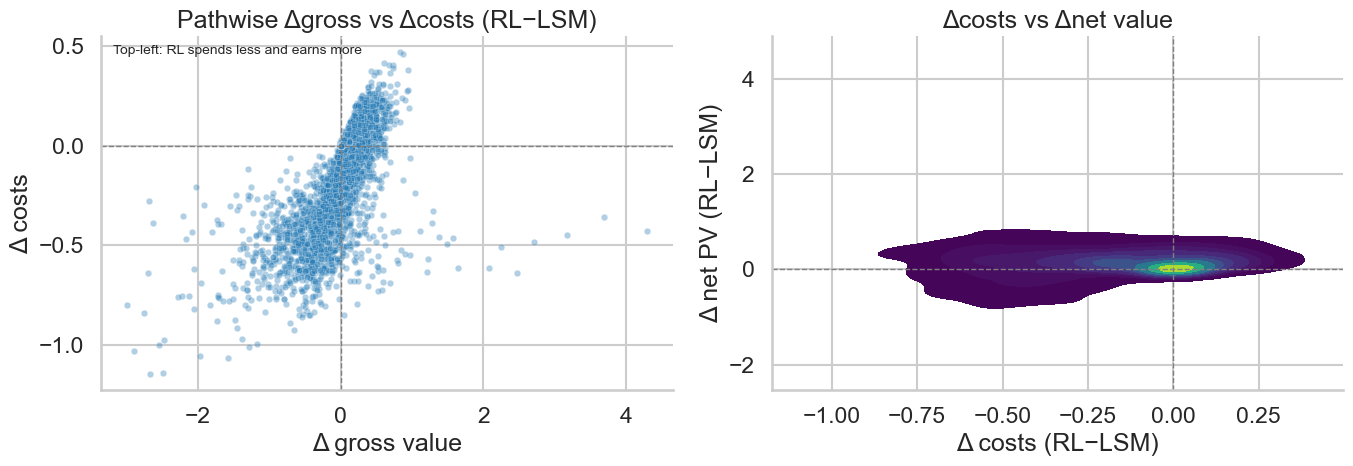

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=paired_costs,
    x='delta_gross',
    y='delta_costs',
    s=22,
    alpha=0.35,
    ax=axes[0]
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Pathwise Δgross vs Δcosts (RL−LSM)')
axes[0].set_xlabel('Δ gross value')
axes[0].set_ylabel('Δ costs')
axes[0].annotate('Top-left: RL spends less and earns more', xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10, ha='left')
sns.kdeplot(
    data=paired_costs,
    x='delta_costs',
    y='delta_PV',
    fill=True,
    thresh=0.05,
    levels=10,
    cmap='viridis',
    ax=axes[1]
)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Δcosts vs Δnet value')
axes[1].set_xlabel('Δ costs (RL−LSM)')
axes[1].set_ylabel('Δ net PV (RL−LSM)')

delta_cost_range = paired_costs['delta_costs']
delta_pv_range = paired_costs['delta_PV']
x_pad = (delta_cost_range.max() - delta_cost_range.min()) * 0.02
x_pad = x_pad if x_pad > 0 else 0.01
y_pad = (delta_pv_range.max() - delta_pv_range.min()) * 0.02
y_pad = y_pad if y_pad > 0 else 0.01
axes[1].set_xlim(delta_cost_range.min() - x_pad, delta_cost_range.max() + x_pad)
axes[1].set_ylim(delta_pv_range.min() - y_pad, delta_pv_range.max() + y_pad)

plt.tight_layout()
plt.show()

### Cost advantage narrative
- RL spends less convex cost on roughly two thirds of the simulated paths while also unlocking higher gross value on a similar share, indicating that policy learning drives both better timing and thriftier volume spreading.
- The joint density plot shows most mass in the lower-right quadrant (Δcosts<0, Δnet>0), confirming that cost suppression explains the bulk of the net premium, with a thinner ridge where RL wins despite higher costs thanks to superior monetisation.

## Allocation efficiency
Link PV vs quantity to infer marginal value of exercising under convex frictions. Efficiency slope = OLS slope of PV on total quantity.

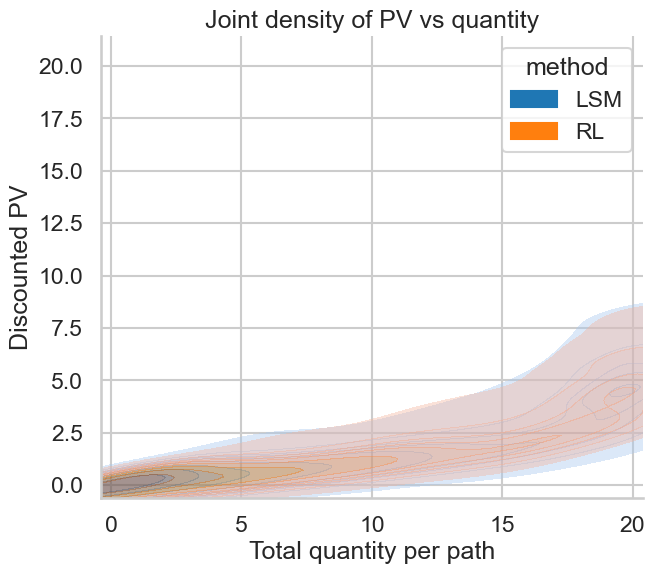

,slope,ci_low,ci_high
method,,,
LSM,0.2389,0.2322,0.2454
RL,0.2472,0.2402,0.2536


In [17]:
def efficiency_slope(series_df: pd.DataFrame, B: int = 1000, seed: int = 0) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    x = series_df['Q_total'].to_numpy()
    y = series_df['PV_net'].to_numpy()
    var_x = np.var(x, ddof=1)
    slope = np.cov(x, y, ddof=1)[0, 1] / var_x
    boots = []
    for _ in range(B):
        idx = rng.integers(0, len(x), size=len(x))
        xb, yb = x[idx], y[idx]
        var_xb = np.var(xb, ddof=1)
        boots.append(np.cov(xb, yb, ddof=1)[0, 1] / var_xb if var_xb > 0 else np.nan)
    boots = np.array(boots)
    return {'slope': slope, 'ci_low': np.nanpercentile(boots, 2.5), 'ci_high': np.nanpercentile(boots, 97.5)}

x_range = path_stats['Q_total']
y_range = path_stats['PV_net']
x_pad = max((x_range.max() - x_range.min()) * 0.02, 0.01)
y_pad = max((y_range.max() - y_range.min()) * 0.02, 0.01)
x_clip = (x_range.min() - x_pad, x_range.max() + x_pad)
y_clip = (y_range.min() - y_pad, y_range.max() + y_pad)

fig, ax = plt.subplots(figsize=(7, 6))
sns.kdeplot(
    data=path_stats,
    x='Q_total',
    y='PV_net',
    hue='method',
    fill=True,
    alpha=0.4,
    thresh=0.05,
    common_norm=False,
    ax=ax,
    palette={'RL': 'tab:orange', 'LSM': 'tab:blue'},
    clip=(x_clip, y_clip)
)
ax.set_title('Joint density of PV vs quantity')
ax.set_xlabel('Total quantity per path')
ax.set_ylabel('Discounted PV')
# ax.set_xlim(x_clip)
# ax.set_ylim(y_clip)
plt.show()

eff_rows = []
for method, grp in path_stats.groupby('method'):
    eff = efficiency_slope(grp)
    eff_rows.append({'method': method, **eff})
eff_df = pd.DataFrame(eff_rows).set_index('method')
eff_df.style.format({"slope": "{:.4f}", "ci_low": "{:.4f}", "ci_high": "{:.4f}"})

## Temporal exercise behaviour
Average and cumulative profiles plus hazard of first exercise show whether convex frictions shift RL timing relative to LSM.

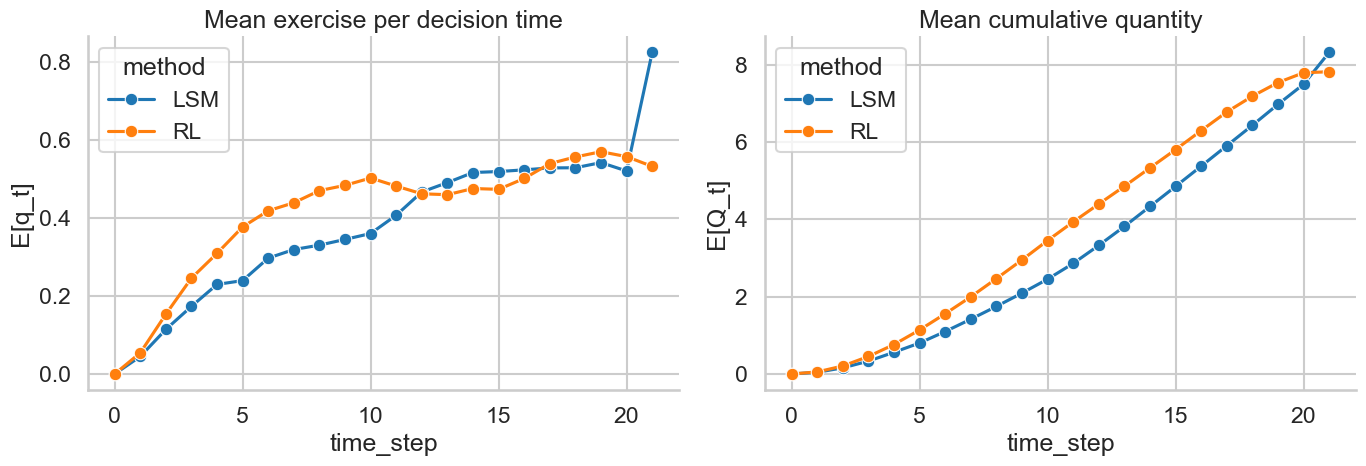

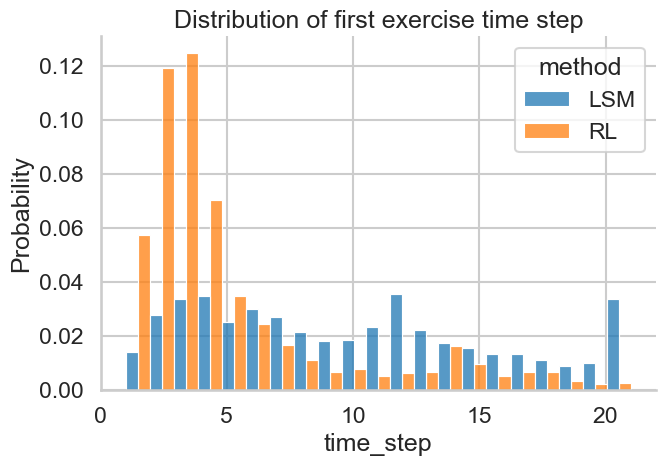

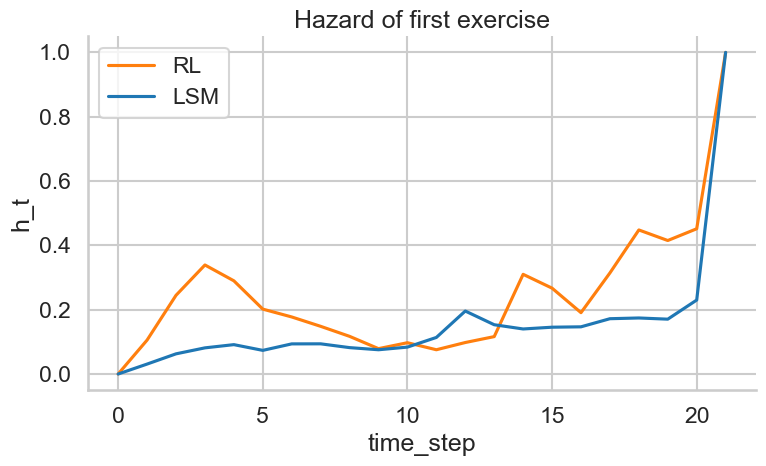

In [18]:
def average_profile(df: pd.DataFrame, label: str) -> pd.DataFrame:
    prof = df.groupby('time_step', as_index=False)['q_t'].mean().rename(columns={'q_t': 'q_mean'})
    prof['method'] = label
    return prof


def cumulative_profile(df: pd.DataFrame, label: str) -> pd.DataFrame:
    tmp = df.sort_values(['path', 'time_step']).copy()
    tmp['cum_q'] = tmp.groupby('path')['q_t'].cumsum()
    prof = tmp.groupby('time_step', as_index=False)['cum_q'].mean().rename(columns={'cum_q': 'cum_q_mean'})
    prof['method'] = label
    return prof


def hazard_curve(first_ex: pd.Series) -> pd.Series:
    s = first_ex.dropna()
    counts = s.value_counts().reindex(range(N_RIGHTS), fill_value=0).astype(float)
    survivors = counts[::-1].cumsum()[::-1]
    hazard = counts / survivors.replace(0, np.nan)
    return hazard

avg_df = pd.concat([average_profile(lsm_df, 'LSM'), average_profile(rl_df, 'RL')], ignore_index=True)
cum_df = pd.concat([cumulative_profile(lsm_df, 'LSM'), cumulative_profile(rl_df, 'RL')], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=avg_df, x='time_step', y='q_mean', hue='method', palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, marker='o', ax=axes[0])
axes[0].set_title('Mean exercise per decision time')
axes[0].set_ylabel('E[q_t]')
sns.lineplot(data=cum_df, x='time_step', y='cum_q_mean', hue='method', palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, marker='o', ax=axes[1])
axes[1].set_title('Mean cumulative quantity')
axes[1].set_ylabel('E[Q_t]')
plt.tight_layout()

fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=path_stats, x='first_ex', hue='method', bins=21, stat='probability', multiple='dodge', palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, ax=ax)
ax.set_title('Distribution of first exercise time step')
ax.set_xlabel('time_step')
plt.tight_layout()

hazard_df = pd.DataFrame({
    'time_step': range(N_RIGHTS),
    'RL': hazard_curve(rl_paths['first_ex']),
    'LSM': hazard_curve(lsm_paths['first_ex'])
})
fig, ax = plt.subplots(figsize=(8,5))
sns.lineplot(data=hazard_df, x='time_step', y='RL', label='RL', color='tab:orange')
sns.lineplot(data=hazard_df, x='time_step', y='LSM', label='LSM', color='tab:blue')
ax.set_title('Hazard of first exercise')
ax.set_ylabel('h_t')
plt.tight_layout()

## State-conditional intensity
Exercise response to moneyness buckets reveals how each method trades off convex costs vs deep ITM opportunities.

/var/folders/57/8q11hb450rz9z_rwvfbzpkmm0000gn/T/ipykernel_72465/3047692909.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/57/8q11hb450rz9z_rwvfbzpkmm0000gn/T/ipykernel_72465/3047692909.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



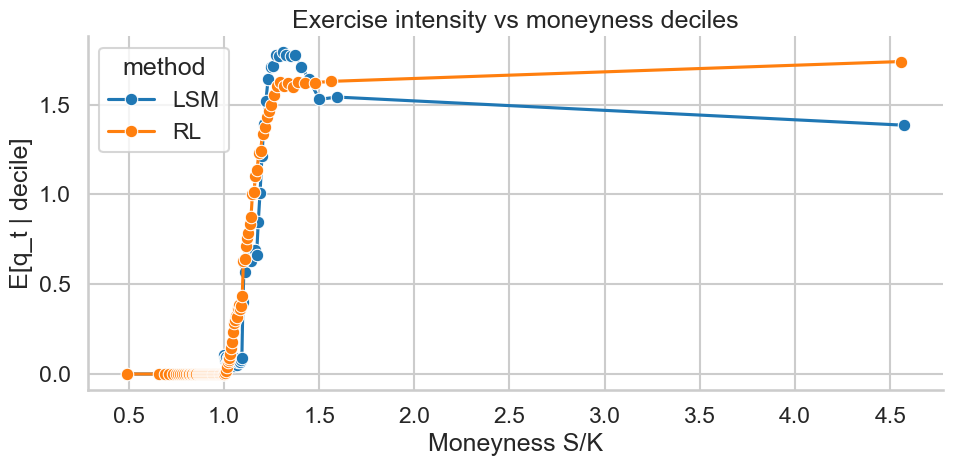

In [23]:
def moneyness_profile(df: pd.DataFrame, label: str, qcap: float = Q_MAX) -> pd.DataFrame:
    tmp = df.copy()
    tmp['mny'] = tmp['spot'] / K
    tmp = tmp[np.isfinite(tmp['mny']) & np.isfinite(tmp['q_t'])]
    tmp['decile'] = pd.qcut(tmp['mny'], q=100, duplicates='drop')
    tmp['mn_mid'] = tmp['decile'].apply(lambda iv: (iv.left + iv.right)/2 if hasattr(iv, 'left') else np.nan)
    prof = tmp.groupby('mn_mid', as_index=False)['q_t'].mean().rename(columns={'q_t': 'q_mean'})
    prof['method'] = label
    return prof.dropna()

mn_df = pd.concat([moneyness_profile(lsm_df, 'LSM'), moneyness_profile(rl_df, 'RL')], ignore_index=True)
plt.figure(figsize=(10,5))
sns.lineplot(data=mn_df, x='mn_mid', y='q_mean', hue='method', palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, marker='o')
plt.title('Exercise intensity vs moneyness deciles')
plt.xlabel('Moneyness S/K')
plt.ylabel('E[q_t | decile]')
plt.tight_layout()

## Pathwise discrepancies
Join matching paths to inspect tails where RL and LSM disagree the most after costs.

In [21]:
paired = (
    rl_paths[['path', 'PV_net', 'Q_total', 'Costs_total', 'cost_per_unit']]
    .merge(
        lsm_paths[['path', 'PV_net', 'Q_total', 'Costs_total', 'cost_per_unit']],
        on='path',
        suffixes=('_RL', '_LSM')
    )
)
paired['delta_PV'] = paired['PV_net_RL'] - paired['PV_net_LSM']
paired['delta_Q'] = paired['Q_total_RL'] - paired['Q_total_LSM']
paired['delta_cost'] = paired['Costs_total_RL'] - paired['Costs_total_LSM']
paired['delta_cost_per_unit'] = paired['cost_per_unit_RL'] - paired['cost_per_unit_LSM']
top_abs = paired.reindex(paired['delta_PV'].abs().sort_values(ascending=False).index).head(10)
top_abs

,path,PV_net_RL,Q_total_RL,Costs_total_RL,cost_per_unit_RL,PV_net_LSM,Q_total_LSM,Costs_total_LSM,cost_per_unit_LSM,delta_PV,delta_Q,delta_cost,delta_cost_per_unit
899,899,13.377460,19.999997,1.273261,0.063663,8.628468,20.0,2.0,0.1,4.748992,-0.000003,-0.726739,-0.036337
3935,3935,12.099535,20.000001,0.232449,0.011622,8.026048,20.0,2.0,0.1,4.073487,0.000001,-1.767551,-0.088378
1471,1471,9.569357,20.000000,0.330007,0.016500,5.933991,20.0,2.0,0.1,3.635366,0.000000,-1.669993,-0.083500
2601,2601,11.437438,19.999997,0.756189,0.037809,8.215759,20.0,2.0,0.1,3.221679,-0.000003,-1.243811,-0.062191
2951,2951,10.002779,20.000000,0.634831,0.031742,6.879503,20.0,2.0,0.1,3.123276,0.000000,-1.365169,-0.068258
2727,2727,8.204349,20.000001,1.153470,0.057673,5.426778,20.0,2.0,0.1,2.777571,0.000001,-0.846530,-0.042327
1671,1671,7.378793,20.000002,1.041342,0.052067,4.678291,20.0,2.0,0.1,2.700502,0.000002,-0.958658,-0.047933
1987,1987,5.599678,20.000002,0.826398,0.041320,7.990755,20.0,2.0,0.1,-2.391077,0.000002,-1.173602,-0.058680
1531,1531,7.436399,19.999999,0.609182,0.030459,5.163133,20.0,2.0,0.1,2.273266,-0.000001,-1.390818,-0.069541
3327,3327,7.103562,20.000000,0.890109,0.044505,9.337033,20.0,2.0,0.1,-2.233471,0.000000,-1.109891,-0.055495
